In [37]:
from matplotlib.ticker import ScalarFormatter
import xml.etree.ElementTree as ET
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import MultipleLocator

thousand_formatter = FuncFormatter(lambda x, pos: f"{int(x/1000)}k")
hour_formatter = FuncFormatter(lambda x, pos: f"{int(x/3600)}")
hour_locator = MultipleLocator(3600)


# -----------------------------
# 1. LOAD SUMMARY.XML
# -----------------------------
def load_summary(file):
    tree = ET.parse(file)
    root = tree.getroot()

    rows = []
    for step in root.findall("step"):
        rows.append({
            "time": float(step.attrib["time"]),
            "running": int(step.attrib["running"]),
            "arrived": int(step.attrib.get("arrived", 0)),
            "meanSpeed": float(step.attrib["meanSpeed"]),
            "meanSpeedRelative": float(step.attrib.get("meanSpeedRelative", "nan")),
            "halting": int(step.attrib.get("halting", 0)),
            "waiting": int(step.attrib.get("waiting", 0)),
            "inserted": int(step.attrib.get("inserted", 0)),
        })

    return pd.DataFrame(rows)


# -----------------------------
# 2. LOAD TRIPINFO.XML
# -----------------------------
def load_tripinfo(file):
    tree = ET.parse(file)
    root = tree.getroot()

    rows = []
    for trip in root.findall("tripinfo"):
        rows.append({
            "duration": float(trip.attrib["duration"]),
            "routeLength": float(trip.attrib["routeLength"]),
            "waitingTime": float(trip.attrib["waitingTime"]),
            "timeLoss": float(trip.attrib["timeLoss"]),
        })

    return pd.DataFrame(rows)


# -----------------------------
# 3. LOAD EDGEDATA.XML
# -----------------------------
def load_edgedata(file):
    tree = ET.parse(file)
    root = tree.getroot()

    rows = []

    for interval in root.findall("interval"):
        t = float(interval.attrib["begin"])

        for edge in interval.findall("edge"):
            rows.append({
                "time": t,
                "edge": edge.attrib["id"],
                "speed": float(edge.attrib.get("speed", 0)),
                "density": float(edge.attrib.get("density", 0)),
                "occupancy": float(edge.attrib.get("occupancy", 0)),
            })

    return pd.DataFrame(rows)

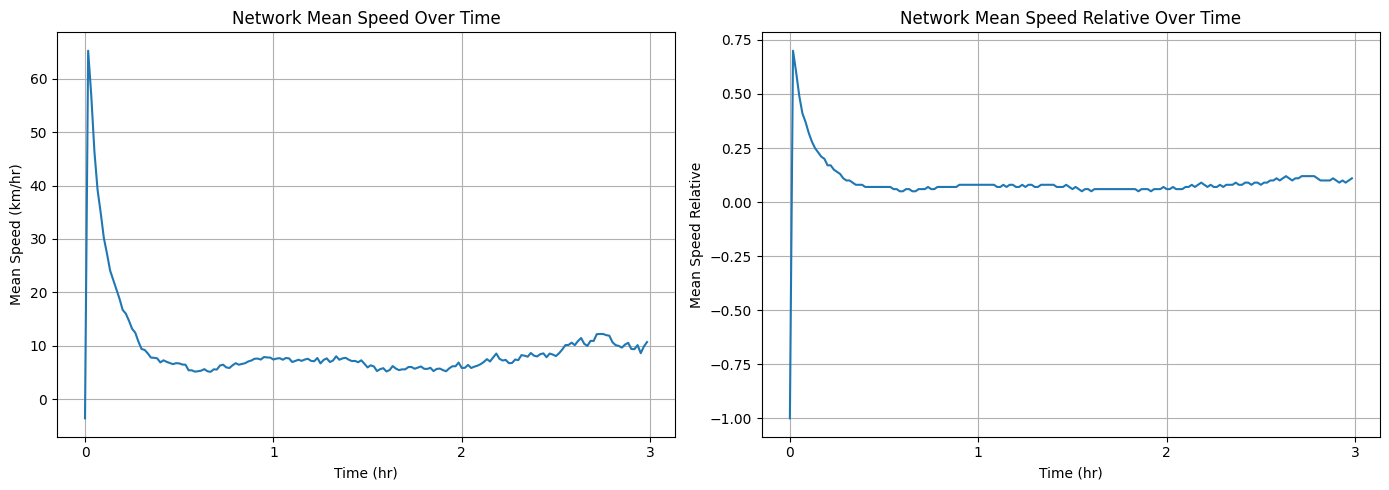

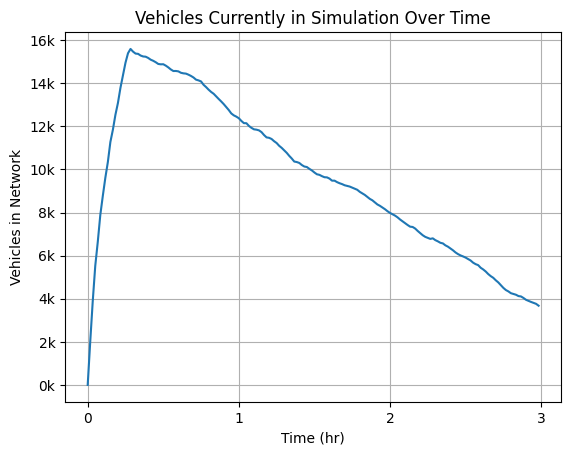

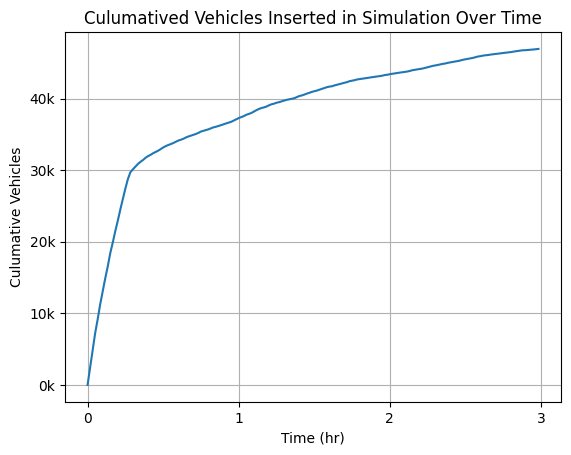

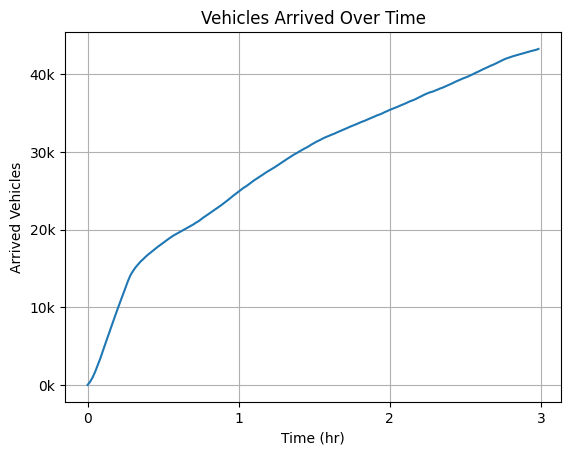

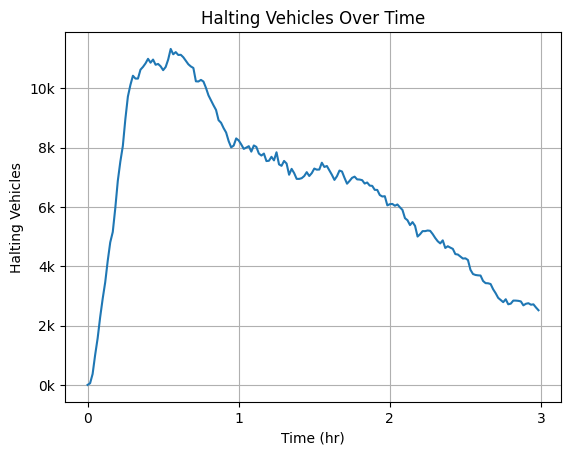

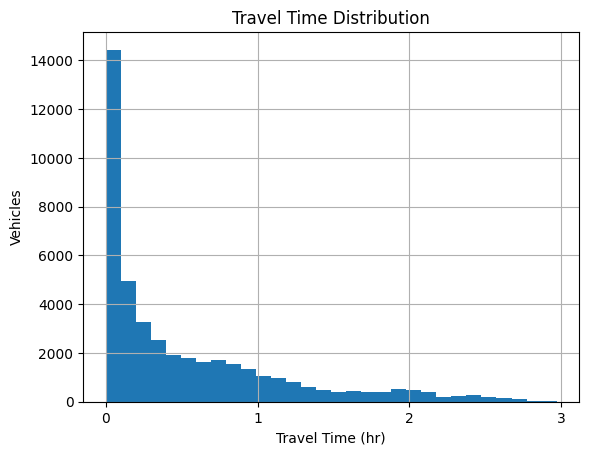

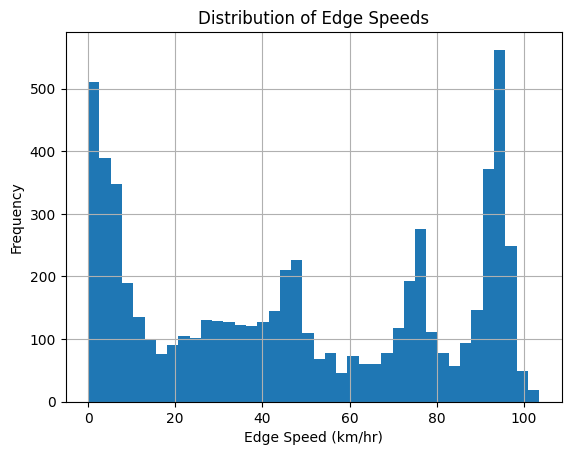

In [41]:
# -----------------------------
# LOAD DATA
# -----------------------------
OutputFolder = "C:/Users/Pirot/Documents/GitHub/FYP-OpenPaths/Simulations/Malta/Output"
summary = load_summary(f"{OutputFolder}/summary.xml")
tripinfo = load_tripinfo(f"{OutputFolder}/tripinfo.xml")
edgedata_bike = load_edgedata(f"{OutputFolder}/edgedata.xml")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -----------------------------
# 1. NETWORK SPEED OVER TIME
# -----------------------------
axes[0].plot(summary["time"], summary["meanSpeed"] * 3.6)
axes[0].set_xlabel("Time (hr)")
axes[0].set_ylabel("Mean Speed (km/hr)")
axes[0].set_title("Network Mean Speed Over Time")
axes[0].xaxis.set_major_formatter(hour_formatter)
axes[0].xaxis.set_major_locator(hour_locator)
axes[0].grid(True)

# -----------------------------
# 2. NETWORK MEAN SPEED RELATIVE OVER TIME
# -----------------------------
if summary["meanSpeedRelative"].notna().any():
    axes[1].plot(summary["time"], summary["meanSpeedRelative"])
    axes[1].set_xlabel("Time (hr)")
    axes[1].set_ylabel("Mean Speed Relative")
    axes[1].set_title("Network Mean Speed Relative Over Time")
    axes[1].xaxis.set_major_formatter(hour_formatter)
    axes[1].xaxis.set_major_locator(hour_locator)
    axes[1].grid(True)
else:
    print("meanSpeedRelative not found in summary.xml")

plt.tight_layout()
plt.show()

# -----------------------------
# 3. VEHICLES RUNNING OVER TIME
# -----------------------------
plt.figure()
plt.plot(summary["time"], summary["running"])
plt.xlabel("Time (hr)")
plt.ylabel("Vehicles in Network")
plt.title("Vehicles Currently in Simulation Over Time")
ax = plt.gca()
ax.yaxis.set_major_formatter(thousand_formatter)
ax.xaxis.set_major_formatter(hour_formatter)
ax.xaxis.set_major_locator(hour_locator)
plt.grid()
plt.show()

# -----------------------------
# 3. Culumatived VEHICLES Inserted Overall OVER TIME
# -----------------------------
plt.figure()
plt.plot(summary["time"], summary["inserted"])
plt.xlabel("Time (hr)")
plt.ylabel("Culumative Vehicles")
plt.title("Culumatived Vehicles Inserted in Simulation Over Time")
ax = plt.gca()
ax.yaxis.set_major_formatter(thousand_formatter)
ax.xaxis.set_major_formatter(hour_formatter)
ax.xaxis.set_major_locator(hour_locator)
plt.grid()
plt.show()

# -----------------------------
# 4. VEHICLES ARRIVED OVER TIME
# -----------------------------
plt.figure()
plt.plot(summary["time"], summary["arrived"])
plt.xlabel("Time (hr)")
plt.ylabel("Arrived Vehicles")
plt.title("Vehicles Arrived Over Time")
ax = plt.gca()
ax.yaxis.set_major_formatter(thousand_formatter)
ax.xaxis.set_major_formatter(hour_formatter)
ax.xaxis.set_major_locator(hour_locator)
plt.grid()
plt.show()

# -----------------------------
# 5. HALTING VEHICLES OVER TIME
# -----------------------------
plt.figure()
plt.plot(summary["time"], summary["halting"])
plt.xlabel("Time (hr)")
plt.ylabel("Halting Vehicles")
plt.title("Halting Vehicles Over Time")
ax = plt.gca()
ax.yaxis.set_major_formatter(thousand_formatter)
ax.xaxis.set_major_formatter(hour_formatter)
ax.xaxis.set_major_locator(hour_locator)
plt.grid()
plt.show()

# -----------------------------
# 6. TRAVEL TIME DISTRIBUTION
# -----------------------------
plt.figure()
tripinfo["duration"].hist(bins=30)
plt.xlabel("Travel Time (hr)")
plt.ylabel("Vehicles")
plt.title("Travel Time Distribution")
ax = plt.gca()
ax.xaxis.set_major_formatter(hour_formatter)
ax.xaxis.set_major_locator(hour_locator)
plt.show()

# -----------------------------
# 7. EDGE SPEED DISTRIBUTION
# -----------------------------
plt.figure()
(edgedata_bike["speed"] * 3.6).hist(bins=40)
plt.xlabel("Edge Speed (km/hr)")
plt.ylabel("Frequency")
plt.title("Distribution of Edge Speeds")
plt.show()

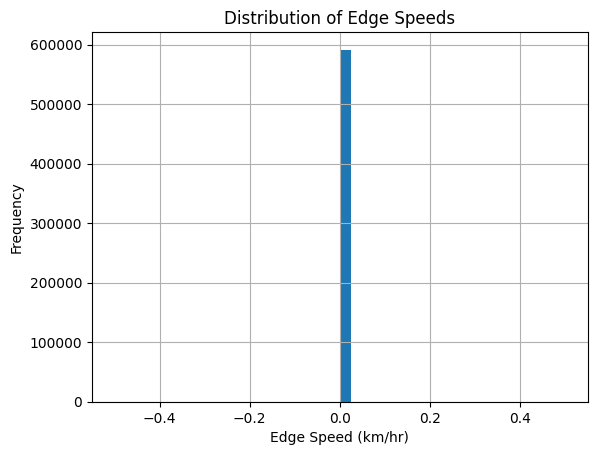

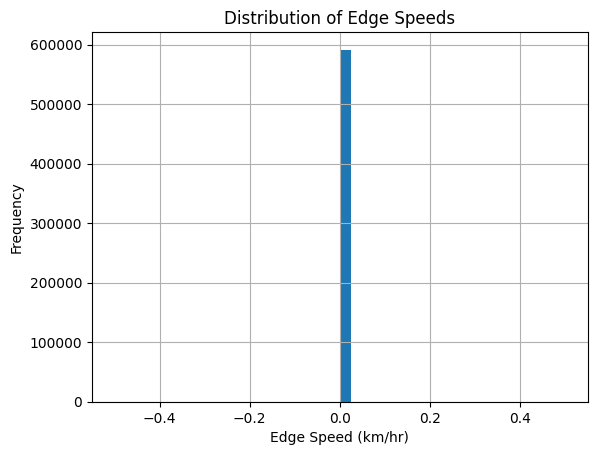

In [39]:
# -----------------------------
# LOAD DATA
# -----------------------------
edgedata_bike = load_edgedata("C:/Users/Pirot/Desktop/Simulation/Gozo/Output2/edgedata_bike.xml")
edgedata_car = load_edgedata("C:/Users/Pirot/Desktop/Simulation/Gozo/Output2/Oedgedata_car.xml")


# -----------------------------
# 4. EDGE SPEED DISTRIBUTION
# -----------------------------
plt.figure()
(edgedata_bike["speed"] * 3.6).hist(bins=40)
plt.xlabel("Edge Speed (km/hr)")
plt.ylabel("Frequency")
plt.title("Distribution of Edge Speeds")
plt.show()

# -----------------------------
# 4. EDGE SPEED DISTRIBUTION
# -----------------------------
plt.figure()
(edgedata_car["speed"] * 3.6).hist(bins=40)
plt.xlabel("Edge Speed (km/hr)")
plt.ylabel("Frequency")
plt.title("Distribution of Edge Speeds")
plt.show()

In [40]:
"""import pandas as pd

summary = pd.read_xml("C:/Users/Pirot/Desktop/Simulation/Output/summary.xml", xpath="//step")

print(summary.head())"""

'import pandas as pd\n\nsummary = pd.read_xml("C:/Users/Pirot/Desktop/Simulation/Output/summary.xml", xpath="//step")\n\nprint(summary.head())'